In [ ]:
'''
Project: Loan Approval Predictor
Dataset columns:

Income
Credit Score
Age
Loan Amount
Employment Years

Steps:

Load dataset
Train Decision Tree
Train Random Forest
Compare accuracy
Show feature importance
Save model using pickle
'''

    Income  Credit Score  Age  Loan Amount  Employment Years  Approved
0    25000           580   22        10000                 1         0
1    45000           670   35        20000                 5         1
2    30000           600   28        15000                 3         0
3    80000           750   45        30000                15         1
4    60000           700   38        25000                10         1
5    90000           780   50        35000                20         1
6    35000           610   25        12000                 2         0
7    70000           730   42        28000                12         1
8    50000           680   33        18000                 7         0
9    95000           800   55        40000                25         1
10   20000           550   21         8000                 1         0
11   55000           690   37        22000                 8         1
12   40000           640   30        16000                 5         0
13   7

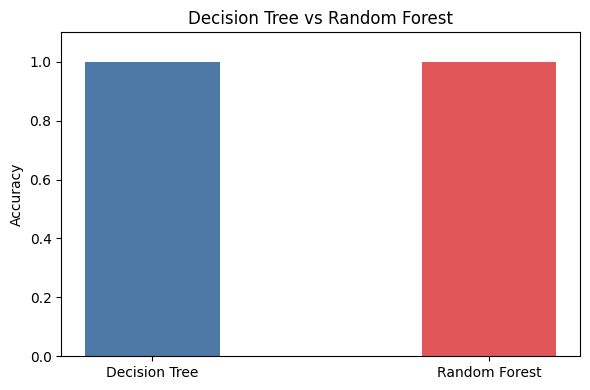


Feature Importance:
             Feature  Importance
3       Loan Amount    0.299812
2               Age    0.282381
1      Credit Score    0.163072
0            Income    0.156345
4  Employment Years    0.098390


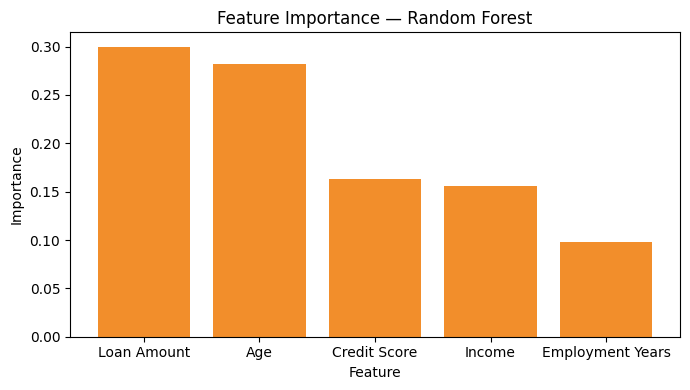

Loan Approved.
Model saved as loan_model.pkl
Model loaded successfully.
Loaded Model Prediction: [1]


C:\Users\aadis\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\aadis\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle
data = {
    "Income":           [25000, 45000, 30000, 80000, 60000, 90000, 35000, 70000, 50000, 95000,
                         20000, 55000, 40000, 75000, 65000],
    "Credit Score":     [580, 670, 600, 750, 700, 780, 610, 730, 680, 800,
                         550, 690, 640, 760, 710],
    "Age":              [22, 35, 28, 45, 38, 50, 25, 42, 33, 55,
                         21, 37, 30, 48, 40],
    "Loan Amount":      [10000, 20000, 15000, 30000, 25000, 35000, 12000, 28000, 18000, 40000,
                         8000,  22000, 16000, 32000, 27000],
    "Employment Years": [1, 5, 3, 15, 10, 20, 2, 12, 7, 25,
                         1, 8,  5, 18, 11],
    "Approved":         [0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
                         0, 1, 0, 1, 1]
}
df = pd.DataFrame(data)
print(df)
X = df.drop("Approved", axis=1)
y = df["Approved"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy    = accuracy_score(y_test, dt_predictions)
print("Decision Tree Predictions:", dt_predictions)
print("Decision Tree Accuracy   :", dt_accuracy)
print("Classification Report:\n",  classification_report(y_test, dt_predictions))
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy    = accuracy_score(y_test, rf_predictions)
print("Random Forest Predictions:", rf_predictions)
print("Random Forest Accuracy   :", rf_accuracy)
print("Classification Report:\n",  classification_report(y_test, rf_predictions))
print("\n===== Accuracy Comparison =====")
print(f"Decision Tree : {round(dt_accuracy, 4)}")
print(f"Random Forest : {round(rf_accuracy, 4)}")
models     = ["Decision Tree", "Random Forest"]
accuracies = [dt_accuracy, rf_accuracy]
plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=["#4e79a7", "#e15759"], width=0.4)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest")
plt.tight_layout()
plt.show()
importance = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)
print("\nFeature Importance:\n", importance)
plt.figure(figsize=(7, 4))
plt.bar(importance["Feature"], importance["Importance"], color="#f28e2b")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()
new_applicant = [[55000, 700, 35, 20000, 8]]
prediction    = rf_model.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Approved.")
else:
    print("Loan Not Approved.")

with open("loan_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved as loan_model.pkl")

with open("loan_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully.")
print("Loaded Model Prediction:", loaded_model.predict(new_applicant))